In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import seaborn as sns

In [2]:
df=pd.read_csv('loan_data.csv.xls')

In [3]:
x = df.drop(columns='loan_status')
y=df.loan_status

In [4]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [5]:
x.corr(numeric_only=True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000


In [6]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

C:\Users\USER\AppData\Local\Temp\ipykernel_14904\4193232358.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols=x.select_dtypes(include='object').columns


<Axes: >

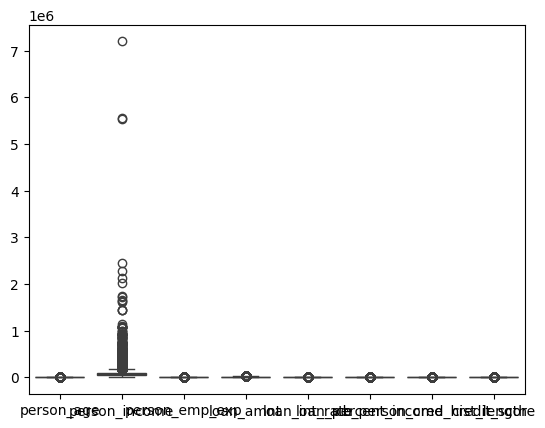

In [7]:
sns.boxplot(x[num_cols])

In [8]:
x[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

In [9]:
encoder=OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling=MinMaxScaler()
model=LogisticRegression()

In [10]:
#xtrain

xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols]=scaling.fit_transform(xtrain[obj_cols])
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()

xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)


In [11]:
#update xtest
xtest[num_cols] = scaling.transform(xtest[num_cols])
encoded_values=encoder.transform(xtest[obj_cols])
xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)



In [12]:
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
#Evaluation
model.score(xtrain,ytrain)


0.8966944444444445

In [14]:
y_pred = model.predict(xtest)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, f1_score 

print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("Accuracy :", accuracy_score(ytest, y_pred))
print("Precision:", precision_score(ytest, y_pred))
print("Recall   :", recall_score(ytest, y_pred))
print("F1 Score :", f1_score(ytest, y_pred))

Confusion Matrix:
 [[6548  442]
 [ 523 1487]]
Accuracy : 0.8927777777777778
Precision: 0.7708657335406947
Recall   : 0.7398009950248756
F1 Score : 0.755013962934755


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, f1_score 

In [17]:
ytrain_pred=model.predict(xtrain)
confusion_matrix(ytrain,ytrain_pred)

array([[26304,  1706],
       [ 2013,  5977]])

In [18]:
y.value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [19]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [20]:
precision_score(ytrain,ytrain_pred)


0.7779513210985293